# End to End Rubin DP2 Simulation

This notebook provides an end to end example of simulating Type Ia supernovae using [sncosmo](https://sncosmo.readthedocs.io/en/stable/)'s SALT II implementation and Rubin's DP2 observations.

## Get the DP2 Survey Data

Users will need to download the CCDVisits table for DP2. This notebook assumes the table has been downloaded to a local directory at: "data/obstable/visit_detector.parquet". A full parquet version of the DP2 Visit Detector table can be found on [LSDB.io](https://data.lsdb.io/hats/dp2/visit_detector.parquet) (~1.3 GB).

Note that the data is provided on a per-detector (CCD) basis. So we will see multiple entries for each time stamp (expMidptMJD).

In [1]:
import pandas as pd

from lightcurvelynx import _LIGHTCURVELYNX_BASE_DIR

filename = f"{_LIGHTCURVELYNX_BASE_DIR}/data/obstable/visit_detector.parquet"
survey_data = pd.read_parquet(filename)
print(f"Loaded {len(survey_data)} rows")
survey_data.head()

Loaded 5150198 rows


,detectorId,visitId,physical_filter,band,ra,dec,pixelScale,zenithDistance,expTime,zeroPoint,...,ulcdec,urcra,urcdec,lrcra,lrcdec,wcsCornerMaxOffset,wcsDetectorPointingResidual,wcsVisitPointingResidual,wcsPreliminaryDetectorPointingResidual,wcsPreliminaryVisitPointingResidual
0,1,2025042400172,r_57,r,183.924159,6.983400,0.199324,37.089813,29.999916,32.158752,...,7.138376,184.080646,6.954931,183.892439,6.828384,0.170347,0.744071,6.553011,0.916436,6.759033
1,2,2025042400172,r_57,r,184.119267,7.114777,0.199386,37.218884,29.999916,32.171349,...,7.269691,184.275856,7.086174,184.087382,6.959794,0.041369,0.706818,5.430327,0.743956,5.477780
2,3,2025042400172,r_57,r,183.860867,6.658387,0.199382,36.765778,29.999916,32.168167,...,6.813479,184.017311,6.630034,183.829391,6.503267,0.030114,0.667091,6.370576,0.689754,6.432752
3,4,2025042400172,r_57,r,184.056165,6.789660,0.199462,36.894409,29.999916,32.176689,...,6.944726,184.212706,6.761139,184.024498,6.634574,0.028227,0.661132,6.271190,0.670319,6.300598
4,5,2025042400172,r_57,r,184.251453,6.921106,0.199489,37.024181,29.999916,32.180489,...,7.076134,184.408082,6.892454,184.219634,6.766038,0.034896,0.656864,5.191592,0.665656,5.237656


We convert this data into an `ObsTable` using the `LSSTObsTable` class's built-in `from_ccdvisit_table()` method. This method includes the schemas for both DP1 (CCDVisit) and DP2 (VisitDetector) data.

Note that we need to set `make_detector_footprint` to True when creating the table. The detector level tables provides one pointing per-ccd. If you do not use a detector footprint (and fallback to a circular areas), the same sampled point can get picked up by multiple CCDs. This will show up as multiple points in the light curve having the same time stamp and filter

We will get a **expected** warnings from the fact that the DP2 table has NaNs in some of the noise columns. We suppress those warnings in the notebook. The corresponding rows are dropped. We drop over 150k rows, leaving a little over 5 million left.

In [2]:
import numpy as np
import warnings

from lightcurvelynx.obstable.lsst_obstable import LSSTObsTable

with warnings.catch_warnings(action="ignore"):
    obs_table = LSSTObsTable.from_ccdvisit_table(survey_data, make_detector_footprint=True)
print(f"Created obs_table with {len(obs_table)} rows")

times = obs_table["time"]
print(f"Times span from {np.min(times)} to {np.max(times)}")

Created obs_table with 5004759 rows
Times span from 60790.11722739659 to 61047.354118603194


As descriped in the [Working with Rubin CCDVisit Table Data notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/pre_executed/rubin_ccdvisit.html), the columns are automatically renamed to match what LightCurveLynx needs. 

We create the rest of the survey information by using the standard LSST passbands and noise model (Poisson).

In [3]:
from lightcurvelynx.astro_utils.passbands import PassbandGroup
from lightcurvelynx.survey_info import SurveyInfo

# On RSP this will download the LSST passbands; pass table_dir= to use a cached copy.
passband_group = PassbandGroup.from_preset(preset="LSST")

# Create a combined SurveyInfo object with the ObsTable, passbands, and (default) noise model.
survey_info = SurveyInfo(obstable=obs_table, passbands=passband_group, survey_name="LSST")

## Create the model

To generate simulated light curves we need to define the properties of the object from which to sample. In this notebook, we use [sncosmo](https://sncosmo.readthedocs.io/en/stable/)'s SALT2 model for Type Ia supernova.

We start by defining how the parameters will be sampled. This includes both SALT2 parameters, such as `x0` and `x1`, as well as general astronomical parameters, such as redshift.

Each of the objects created below is sampler for a single parameter. Some samplers are simple. For example, `redshift_sampler` defines uniform sampling from [0.01, 0.2). Other samples, such as `X0FromDistMod` compute the parameter's values as a function of the sampled values of other parameters. For more information on parameter sampling and how to chain parameter definitions, see the [Sampling Parameters notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/sampling.html). For detail on sampling positions (RA, dec), see the [Sampling (RA, dec) notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/sampling_positions.html). 


In [4]:
from lightcurvelynx.astro_utils.snia_utils import DistModFromRedshift, X0FromDistMod
from lightcurvelynx.math_nodes.np_random import NumpyRandomFunc
from lightcurvelynx.math_nodes.ra_dec_sampler import ApproximateMOCSampler


# Sample redshift uniformly between 0.01 and 0.2.
redshift_sampler = NumpyRandomFunc("uniform", low=0.01, high=0.2)

# Sample position (RA, dec) uniformly from the footprint of the survey. This sampler
# will take multiple seconds to build as it creates a MOC of the survey footprint.
coverage_sampler = ApproximateMOCSampler.from_obstable(obs_table, depth=10)

# Use given values the cosmological parameters (H0=73.0, Omega_m=0.3).
# Then compue the distance modulus from the redshift (taking the redshift sampler as input).
distmod_func = DistModFromRedshift(redshift_sampler, H0=73.0, Omega_m=0.3)

# Sample x1, c, and m_abs from distributions motivated by typical SNIa values.
x1_func = NumpyRandomFunc("normal", loc=0, scale=2.0)
c_func = NumpyRandomFunc("normal", loc=0, scale=0.02)
m_abs_func = NumpyRandomFunc("normal", loc=-19.3, scale=0.1)

# Compute x0 from the other parameters using the standard Tripp formula,
# and the distance modulus from above.
x0_func = X0FromDistMod(
    distmod=distmod_func,  # Use the computed distance modulus from redshift as input.
    x1=x1_func,  # Use the sampled x1 values as input.
    c=c_func,  # Use the sampled c values as input.
    alpha=0.14,  # Use a constant alpha value motivated by typical SNIa fits.
    beta=3.1,  # Use a constant beta value motivated by typical SNIa fits.
    m_abs=m_abs_func,  # Use the sampled m_abs values as input.
)

# t0 for the supernova is sampled uniformly over the time range of the observations.
t0_func = NumpyRandomFunc("uniform", low=np.min(times), high=np.max(times))

We then define the model using the `SncosmoWrapperModel` class. All of the parameters are set using the samplers defined above.

Since sncosmo's SALT2 model is only defined over a limited range of phase space (times), we need to specify how to handle points outside that range. We don't want the flux to immediately drop to zero, because that produces unrealistic artifacts. Instead we use one of the extrapolation functions built into LightCurveLynx. In this case we will use a linear decay to zero over 50 days. More types of extrapolation and more discussion of how to use them can be found in the [extrapolation notebook](https://lightcurvelynx.readthedocs.io/en/latest/notebooks/extrapolation.html).

In [5]:
from lightcurvelynx.models.sncosmo_models import SncosmoWrapperModel
from lightcurvelynx.utils.extrapolate import LinearDecay

time_extrapolation = LinearDecay(50.0)

source = SncosmoWrapperModel(
    "salt2-h17",  # Model name
    t0=t0_func,
    x0=x0_func,
    x1=x1_func,
    c=c_func,
    ra=coverage_sampler.ra,
    dec=coverage_sampler.dec,
    redshift=redshift_sampler,
    node_label="source",
    time_extrapolation=time_extrapolation,  # Use linear extrapolation
)

## Generate the simulations

We can now generate random simulations with all the information defined above. The light curves are written in the [nested-pandas](https://github.com/lincc-frameworks/nested-pandas) format for easy analysis.

In [6]:
from lightcurvelynx.simulate import simulate_lightcurves

lightcurves = simulate_lightcurves(
    source,  # The model we are simulating.
    500,  # The number of simulations to run,
    survey_info,  # The survey info object containing the ObsTable and PassbandGroup.
    # rest_time_window_offset=(-50, 100),  # Simulate from -50 to +100 days of t0 in the rest frame.
)

# Drop the parameters column to make the output more concise, but save it for generating
# the noise-free lightcurves in the plotting section below.
params_col = lightcurves["params"].copy()
lightcurves = lightcurves.drop(columns=["params"])
lightcurves.head()

Simulating:  61%|██████    | 306/500 [00:00<00:00, 3048.06obj/s]/Users/jkubica/h/lightcurvelynx/src/lightcurvelynx/noise_models/noise_utils.py:81: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(total_variance) * zp
Simulating: 100%|██████████| 500/500 [00:00<00:00, 2943.47obj/s]


id          ra        dec  nobs            t0         z  \
0   0   22.262160 -16.733215     2  60807.036083  0.194319   
1   1  107.711715   0.881852     2  60802.201223  0.113864   
2   2   88.548212   7.972698     1  60955.475647  0.068909   
3   3  103.170846 -35.312120    17  60837.091264  0.157509   
4   4   64.774007 -52.807908    13  60939.551750  0.185845   

                                          lightcurve  
0  [{mjd: 61008.10017, filter: 'i', flux: -26.122...  
1  [{mjd: 61033.290243, filter: 'g', flux: 27.687...  
2  [{mjd: 61009.190903, filter: 'z', flux: 43009....  
3  [{mjd: 61007.20313, filter: 'i', flux: -6.5098...  
4  [{mjd: 60976.332305, filter: 'r', flux: 4436.5...

We plot the first 3 results that contain enough sampled points to be interesting.

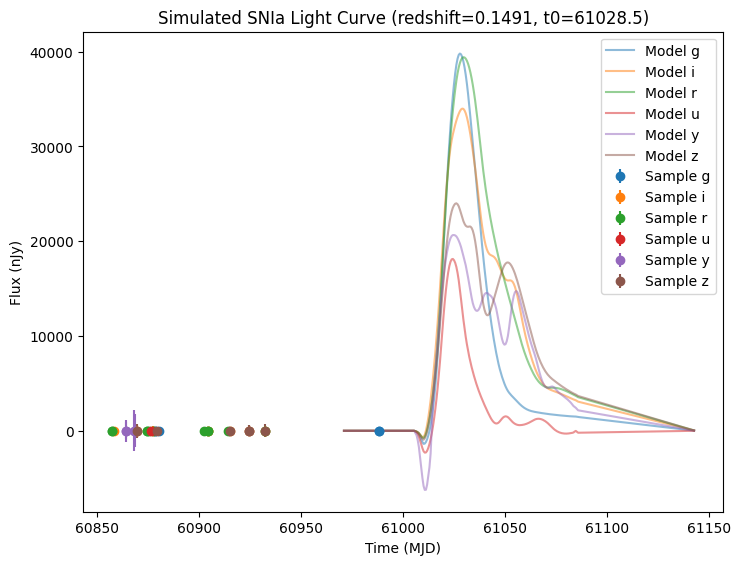

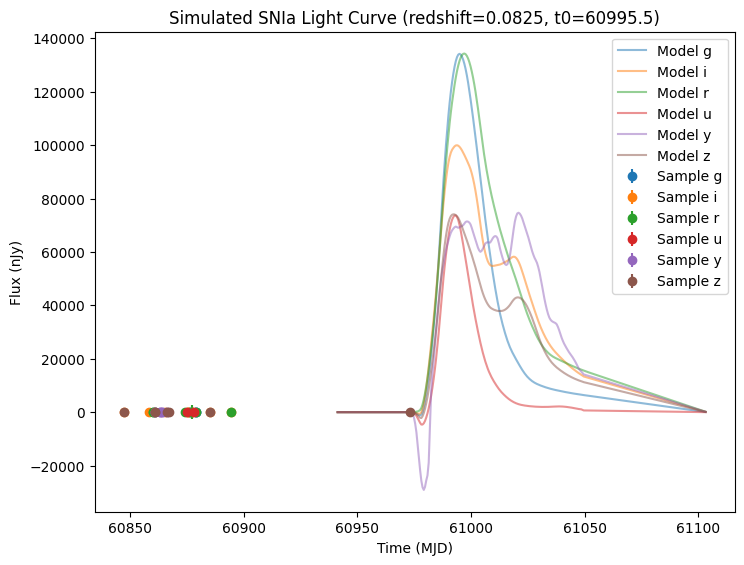

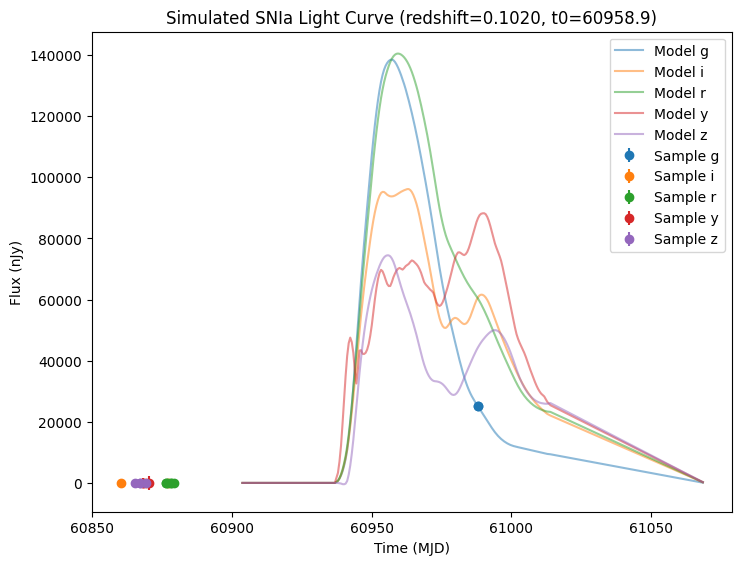

In [7]:
from lightcurvelynx.graph_state import GraphState
from lightcurvelynx.simulate import compute_single_noise_free_lightcurve
from lightcurvelynx.utils.plotting import plot_lightcurves


curr_idx = 0
count = 0
while count < 3:
    # Extract the row for this object.
    result_row = lightcurves.iloc[curr_idx]
    params_dict = params_col.iloc[curr_idx]
    curr_idx += 1

    # If we didn't observe the object at all, skip it. This can happen because
    # we are using approximate position sampling.
    current_lc = result_row["lightcurve"]
    if current_lc is None or len(current_lc) == 0:
        continue

    # Unpack the nested columns (filters, mjd, flux, and flux error). This is the
    # data from the simulation itself.
    lc_filters = np.asarray(current_lc["filter"], dtype=str)
    lc_mjd = np.asarray(current_lc["mjd"], dtype=float)
    lc_flux = np.asarray(current_lc["flux_perfect"], dtype=float)
    lc_fluxerr = np.asarray(current_lc["fluxerr"], dtype=float)

    # If the light curve has only a few observations or covers a very short time span, skip it.
    if len(lc_mjd) < 5 or (np.max(lc_mjd) - np.min(lc_mjd)) < 100:
        continue

    # Extract the parameters used during the simulation of this object (stored in the "params" column).
    # Use that to compute the noise-free light curve for this object, which we will plot alongside the
    # simulated light curve.
    noise_free_lcs = compute_single_noise_free_lightcurve(
        source,
        GraphState.from_dict(params_dict),
        passband_group,
        rest_frame_phase_min=-50.0,  # 50 days before t0
        rest_frame_phase_max=100.0,  # 100 days after t0
        rest_frame_phase_step=0.5,  # 2 samples per day
    )

    # Extract some parameters for the title of the plot.
    redshift = params_dict["source.redshift"]
    t0 = params_dict["source.t0"]

    plot_lightcurves(
        fluxes=lc_flux,
        times=lc_mjd,
        fluxerrs=lc_fluxerr,
        filters=lc_filters,
        underlying_model=noise_free_lcs,
        title=f"Simulated SNIa Light Curve (redshift={redshift:.4f}, t0={t0:.1f})",
    )
    count += 1